# Wind Spectrum Analysis
## Importing Libraries

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pyarrow

## Reading In Datasets

In [24]:
# load in turbine and met masts datasets
scada = pd.read_parquet('../../data/cleaned/scada_data.parquet')
metmasts = pd.read_parquet('../../data/cleaned/metmasts_data.parquet')

In [25]:
# extracting unique turbines
scada['turbine'].unique()

<ArrowStringArray>
['WTG150', 'WTG151', 'WTG152', 'WTG153', 'WTG154', 'WTG155', 'WTG156',
 'WTG157', 'WTG158', 'WTG159', 'WTG161', 'WTG162', 'WTG163', 'WTG164',
 'WTG165', 'WTG166', 'WTG167', 'WTG168', 'WTG169', 'WTG170', 'WTG171',
 'WTG172', 'WTG173', 'WTG174', 'WTG175', 'WTG176', 'WTG177', 'WTG178',
 'WTG179', 'WTG180', 'WTG181', 'WTG182', 'WTG183', 'WTG184', 'WTG185',
 'WTG186', 'WTG187', 'WTG188', 'WTG189', 'WTG190', 'WTG191', 'WTG192',
 'WTG193', 'WTG194', 'WTG195', 'WTG196', 'WTG197']
Length: 47, dtype: str

## Individual Turbines Wind Speed Distributions

In [5]:
# isolating the WTG150 wind turbine
WTG150 = scada[scada['turbine'] == 'WTG150']

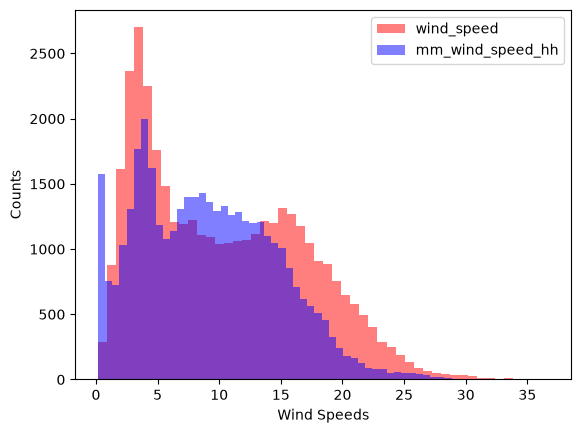

In [6]:
WTG150['wind_speed'].plot.hist(bins = 50, alpha = 0.5, color = 'red')
metmasts['mm_wind_speed_hh'].plot.hist(bins = 50, alpha = 0.5, color = 'blue')
plt.legend()
plt.xlabel('Wind Speeds')
plt.ylabel('Counts')
plt.show()

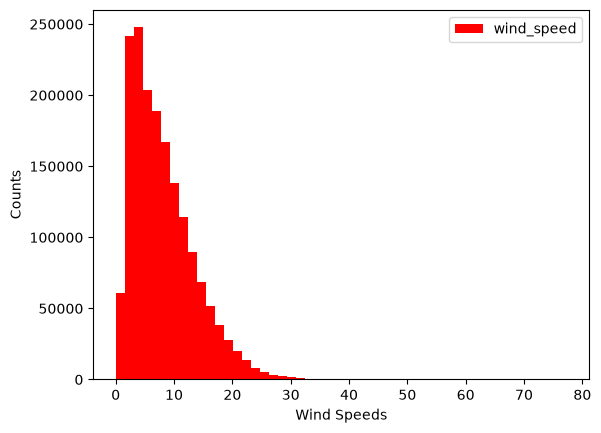

In [9]:
scada['wind_speed'].plot.hist(bins = 50, color = 'red')
plt.legend()
plt.xlabel('Wind Speeds')
plt.ylabel('Counts')
plt.show()

## Time Series Analysis

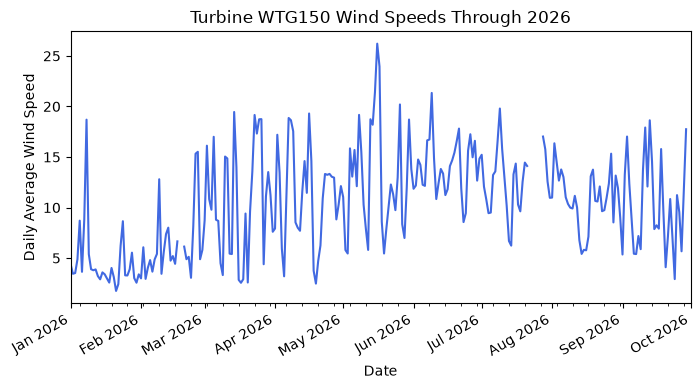

In [56]:
# creating daily averages of wind speeds for easier visualization of longer trends
WTG150_daily = WTG150.resample('D', on = 'utc')['wind_speed'].mean().reset_index()

# defining start and stop time for the x axis
start = pd.Timestamp('2026-01-01')
end = pd.Timestamp('2026-10-01')

# plotting
ax = WTG150_daily.plot('utc', 'wind_speed', color = 'royalblue', figsize = (8, 4), legend = False)
ax.set_xlim(start, end)
ax.xaxis.set_major_locator(mdates.MonthLocator())        
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.figure.autofmt_xdate()
ax.set_title('Turbine WTG150 Wind Speeds Through 2026')
ax.set_xlabel('Date')
ax.set_ylabel('Daily Average Wind Speed')
plt.show()

In [41]:
# looking at missing data for turbine WTG150
WTG150[WTG150['utc'].between('2026-07-22', '2026-07-27')]

,utc,turbine,aid_density,KPI_temp_ambient_merged,KPI_temp_ambient,KPI_theoretical_power,KPI_real_power_ac,real_power_ac,KPI_wind_speed,wind_speed,wind_direction,wind_direction_relative,nacelle_pos,blade_1_pos,blade_2_pos,blade_3_pos,blade_1_setpos,blade_2_setpos,blade_3_setpos
1364880,2026-07-22 00:00:00,WTG150,1.022319,30.790910,NaN,2316.1753,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1364927,2026-07-22 00:10:00,WTG150,1.022319,30.790910,NaN,2316.1753,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1364974,2026-07-22 00:20:00,WTG150,1.022319,30.790910,NaN,2316.1753,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1365021,2026-07-22 00:30:00,WTG150,1.022319,30.790910,NaN,2316.1753,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1365068,2026-07-22 00:40:00,WTG150,1.022319,30.790910,NaN,2316.1753,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1398532,2026-07-26 23:20:00,WTG150,1.015518,33.072727,NaN,1410.8533,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1398579,2026-07-26 23:30:00,WTG150,1.015518,33.072727,NaN,1410.8533,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1398626,2026-07-26 23:40:00,WTG150,1.015518,33.072727,NaN,1410.8533,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1398673,2026-07-26 23:50:00,WTG150,1.015518,33.072727,NaN,1410.8533,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
